# FX Pairs: Feature Evaluation

This notebook evaluates the financial and model-based features against the
primary one-day forward return. Every statistic uses the exact out-of-sample
validation rows from the canonical walk-forward folds. The 2024-2025 holdout
remains sealed for the final selected strategy.

**Learning objectives**

- screen feature coverage and staleness before testing predictive association
- estimate daily cross-sectional IC with Newey-West inference
- control the false discovery rate across the full feature set
- distinguish cross-sectional signals from market-level conditioning variables

**Book reference**: Chapter 7, Section 7.3 (univariate feature-label evaluation) and
Section 7.4 (search accounting and multiple testing)

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py`

**Outputs**

- `evaluation/triage_ledger.parquet`: one diagnostic decision per feature
- `evaluation/ic_timeseries.parquet`: daily validation IC by feature and fold, which
  this notebook reads back to draw the IC series and its uncertainty band

In [1]:
"""Evaluate FX financial and model-based features on canonical validation folds."""

import warnings
from datetime import date

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from utils.artifact_specs import resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.data_quality import validate_modeling_inputs
from utils.paths import get_case_study_dir
from utils.style import COLORS

# The library's HAC-bandwidth guard is the warning most worth seeing here, so the
# suppression names the one category that would otherwise bury it.
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Production defaults. Papermill can reduce symbols or folds for a smoke test.
MAX_SYMBOLS = 0
MAX_FOLDS = 0

## Configuration

Every window, label and boundary below is read from `config/setup.yaml`, which is the
same file the label and feature stages bound their own parameters from. The forward
horizon in bars comes from each label's declared buffer, so the Newey-West bandwidth
and the holdout seal both follow the label rather than a typed constant.

Two thresholds are judgments rather than measurements, and are stated as such.
`IC_THRESHOLD` is the effect-size floor the exploration arm promotes above: it sits an
order of magnitude below the daily IC an FX rank strategy needs to clear the spread it
pays, so clearing it means clearing a floor and not passing a test. `REDUNDANCY_CUT`
is where two features stop counting as separate evidence.

In [3]:
CASE_STUDY_ID = "fx_pairs"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
evaluation_config = load_evaluation_config(CASE_STUDY_ID)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
LABEL_COL = setup["labels"]["primary"]
LABEL_BUFFERS = {LABEL_COL: setup["labels"]["buffer"], **setup["labels"]["variant_buffers"]}
LABEL_HORIZONS = {name: int(buffer.rstrip("Dd")) for name, buffer in LABEL_BUFFERS.items()}
LABEL_HORIZON = LABEL_HORIZONS[LABEL_COL]
HOLDOUT_START = date.fromisoformat(str(evaluation_config["holdout_start"]))
N_QUANTILES = 5
MIN_FOLD_DAYS = 5  # decision times a fold needs before its mean IC is reported
REDUNDANCY_CUT = 0.70  # |Spearman| above which two features are treated as one cluster

IC_THRESHOLD = 0.005
STABILITY_THRESHOLD = 0.60  # share of folds that must share the feature's own direction

print(f"Primary label {LABEL_COL} over {LABEL_HORIZON} session(s); holdout opens {HOLDOUT_START}")
print(f"Declared label horizons: {LABEL_HORIZONS}")

Primary label fwd_ret_1d over 1 session(s); holdout opens 2024-01-01
Declared label horizons: {'fwd_ret_1d': 1, 'fwd_ret_5d': 5, 'fwd_ret_21d': 21}


## 1. Build the Out-of-Sample Validation Panel

The model-based artifact contains training and validation rows for every fold.
Selecting a single duplicate row would silently attach later-fit parameters to
earlier dates. Instead, we keep only each fold's explicit validation interval
and preserve `fold` as provenance throughout evaluation.

In [4]:
financial = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
model_based = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet")
labels = pl.read_parquet(CASE_DIR / "labels" / f"{LABEL_COL}.parquet")

required_temporal = {*JOIN_COLS, "fold"}
missing_temporal = required_temporal.difference(model_based.columns)
if missing_temporal:
    raise ValueError(f"Model-based artifact lacks fold provenance: {sorted(missing_temporal)}")

### Derive the Fold Boundaries, and Seal Them in the Same Call

`generate_cv_splits` reads the label calendar and the walk-forward window declared
in `setup.yaml`, which is the route `04_model_based_features` took when it stamped
the `fold` column this notebook joins on. Deriving them again here rather than
replaying a stored splits array is what keeps a `fold` id naming the same window on
both sides of the join.

The `outcome_horizon` argument is the holdout seal. It drops validation timestamps
whose forward label would settle at or after the holdout opens, counted by position
on the panel's own trading grid rather than in calendar days, so a signal is
eligible only when the bar its label settles on is still inside development.

In [5]:
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, LABEL_COL, setup)
UNIQUE_DATES = labels.select(DATE_COL).unique().sort(DATE_COL)


def fold_windows(outcome_horizon: str) -> list[dict]:
    """Canonical walk-forward folds, with validation sealed at one outcome horizon."""
    splits = generate_cv_splits(
        UNIQUE_DATES,
        case_study_id=CASE_STUDY_ID,
        label_buffer=LABEL_BUFFER,
        outcome_horizon=outcome_horizon,
    )
    return splits[:MAX_FOLDS] if MAX_FOLDS > 0 else splits


def validation_rows(splits: list[dict]) -> pl.DataFrame:
    """Each fold's own validation interval, taken from the fold it was fitted out of."""
    frames = []
    for split in splits:
        rows = model_based.filter(
            (pl.col("fold") == int(split["fold"]))
            & pl.col(DATE_COL).is_between(
                pd.Timestamp(split["val_start"]).date(),
                pd.Timestamp(split["val_end"]).date(),
                closed="both",
            )
        )
        if not len(rows):
            raise ValueError(
                f"Fold {split['fold']} contributes no rows between {split['val_start']} "
                f"and {split['val_end']}; the artifact's fold ids do not match these windows"
            )
        frames.append(rows)
    return pl.concat(frames).sort([DATE_COL, "symbol"])

In [6]:
splits = fold_windows(LABEL_BUFFER)
validation_temporal = validation_rows(splits)
duplicate_keys = validation_temporal.group_by(JOIN_COLS).len().filter(pl.col("len") > 1)
if len(duplicate_keys):
    raise ValueError("Canonical validation folds overlap on timestamp and symbol")

for split in splits:
    print(
        f"  Fold {split['fold']}: validation "
        f"{pd.Timestamp(split['val_start']).date()}..{pd.Timestamp(split['val_end']).date()}"
    )

  Fold 0: validation 2023-01-03..2023-12-28
  Fold 1: validation 2022-01-03..2022-12-30
  Fold 2: validation 2021-01-05..2021-12-31
  Fold 3: validation 2020-01-06..2021-01-04
  Fold 4: validation 2019-01-04..2020-01-03
  Fold 5: validation 2018-01-04..2019-01-03
  Fold 6: validation 2017-01-04..2018-01-03
  Fold 7: validation 2016-01-05..2017-01-03


In [7]:
eval_panel = (
    validation_temporal.join(financial, on=JOIN_COLS, how="inner")
    .join(labels, on=JOIN_COLS, how="inner")
    .sort([DATE_COL, "symbol"])
)

if MAX_SYMBOLS > 0:
    selected_symbols = sorted(eval_panel["symbol"].unique().to_list())[:MAX_SYMBOLS]
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(selected_symbols))

financial_cols = [column for column in financial.columns if column not in JOIN_COLS]
temporal_cols = [column for column in model_based.columns if column not in {*JOIN_COLS, "fold"}]
all_feature_cols = financial_cols + temporal_cols

### Verify the Joined Panel

The seal was applied when the folds were derived, and the assertion below proves it
held on the joined frame, which is the one every statistic in this notebook is
computed on. The frame must also remain unique on its key. The minimum cross-section
a date needs before it contributes an IC is derived from the universe actually
loaded, so a reduced run shrinks the gate with it rather than screening every date
out.

In [8]:
assert eval_panel[DATE_COL].max() < HOLDOUT_START, "Evaluation panel reaches the sealed holdout"
if eval_panel.select(JOIN_COLS).n_unique() != len(eval_panel):
    raise ValueError("Evaluation panel has duplicate timestamp-symbol rows")

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
MIN_PERIODS = max(3, n_symbols // 4)
print(
    f"Validation panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} dates, "
    f"{eval_panel['fold'].n_unique()} folds"
)
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} model-based "
    f"= {len(all_feature_cols)} total"
)
print(
    f"Window: {eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}; "
    f"label endpoints < {HOLDOUT_START}; minimum cross-section {MIN_PERIODS}"
)

Validation panel: 41,260 rows, 20 symbols, 2,063 dates, 8 folds
Features: 53 financial + 10 model-based = 63 total
Window: 2016-01-05 to 2023-12-28; label endpoints < 2024-01-01; minimum cross-section 5


## 2. Input and Correctness Gates

Coverage is measured only on the validation panel. Staleness compares each
pair with its own prior observation in chronological order.

In [9]:
validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=LABEL_COL,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=0.5,
    fail_on_critical=True,
)

Data Quality Gate: 0 CRITICAL, 1 WARNING
  [!] WARNING: 1 features have values |x| > 1e+06: kalman_smoothness(29912)


{'issues': ['WARNING: 1 features have values |x| > 1e+06: kalman_smoothness(29912)'],
 'n_critical': 0,
 'n_warning': 1}

In [10]:
coverage = {}
staleness = {}
for feature in all_feature_cols:
    non_null = eval_panel.filter(pl.col(feature).is_not_null())
    if len(non_null) == 0:
        coverage[feature] = 0.0
    else:
        first_date = non_null[DATE_COL].min()
        eligible = eval_panel.filter(pl.col(DATE_COL) >= first_date)
        coverage[feature] = len(non_null) / len(eligible)

    chronological = eval_panel.select(JOIN_COLS + [feature]).sort(["symbol", DATE_COL])
    unchanged = chronological.select(
        (pl.col(feature) == pl.col(feature).shift(1).over("symbol")).sum()
    ).item()
    comparable = chronological.select(
        pl.col(feature).shift(1).over("symbol").is_not_null().sum()
    ).item()
    staleness[feature] = float(unchanged) / max(comparable, 1)

correctness = {
    feature: coverage[feature] >= 0.70 and staleness[feature] <= 0.50
    for feature in all_feature_cols
}
failed_features = [feature for feature, passed in correctness.items() if not passed]
print(
    f"Correctness gate: {len(correctness) - len(failed_features)} PASS, {len(failed_features)} FAIL"
)
if failed_features:
    print(
        pl.DataFrame(
            {
                "feature": failed_features,
                "coverage": [coverage[feature] for feature in failed_features],
                "staleness": [staleness[feature] for feature in failed_features],
            }
        ).sort("feature")
    )

Correctness gate: 59 PASS, 4 FAIL
shape: (4, 3)
┌──────────────────┬──────────┬───────────┐
│ feature          ┆ coverage ┆ staleness │
│ ---              ┆ ---      ┆ ---       │
│ str              ┆ f64      ┆ f64       │
╞══════════════════╪══════════╪═══════════╡
│ rank_ret_126d    ┆ 1.0      ┆ 0.514719  │
│ rank_sharpe_126d ┆ 1.0      ┆ 0.50662   │
│ rank_vol_gk_21d  ┆ 1.0      ┆ 0.667047  │
│ rank_vol_gk_63d  ┆ 1.0      ┆ 0.845757  │
└──────────────────┴──────────┴───────────┘


Some features are common market states: every pair receives the same value on
a date. They can condition a multivariate model but cannot produce a
cross-sectional IC. We separate them before association testing.

In [11]:
date_level_features = []
for feature in all_feature_cols:
    if not correctness[feature]:
        continue
    values_per_date = eval_panel.group_by(DATE_COL).agg(
        pl.col(feature).drop_nulls().n_unique().alias("n_values")
    )
    fraction_constant = float((values_per_date["n_values"] <= 1).mean())
    if fraction_constant > 0.90:
        date_level_features.append(feature)

print(f"Date-level conditioning variables: {date_level_features}")

Date-level conditioning variables: ['usd_factor_1d', 'usd_factor_21d', 'usd_factor_63d', 'hmm_regime_prob_high_vol', 'hmm_regime_transition_5d']


## 3. Daily Cross-Sectional IC and Newey-West Inference

IC is computed across pairs at each decision date and then averaged. The
sorted daily series is the input to Newey-West; it is never pooled across
dates or averaged from fold summaries.

In [12]:
def compute_cross_sectional_ic(
    df: pl.DataFrame,
    feature: str,
    return_col: str,
    min_periods: int = 5,
) -> pl.DataFrame:
    """Return sorted daily Spearman IC with canonical fold provenance."""
    rows = []
    for group in df.partition_by(DATE_COL, maintain_order=True):
        valid = group.select([feature, return_col]).drop_nulls()
        if len(valid) < min_periods:
            continue
        ic, _ = spearmanr(valid[feature].to_numpy(), valid[return_col].to_numpy())
        if np.isfinite(ic):
            rows.append(
                {
                    DATE_COL: group[DATE_COL][0],
                    "fold": int(group["fold"][0]),
                    "ic": float(ic),
                    "n_obs": len(valid),
                }
            )
    return pl.DataFrame(rows).sort(DATE_COL) if rows else pl.DataFrame()

In [13]:
evaluable_features = [
    feature
    for feature in all_feature_cols
    if correctness[feature] and feature not in date_level_features
]

ic_results = {}
ic_timeseries = {}
for feature in evaluable_features:
    ic_series = compute_cross_sectional_ic(
        eval_panel, feature=feature, return_col=LABEL_COL, min_periods=MIN_PERIODS
    )
    if len(ic_series) < 20:
        continue
    ic_timeseries[feature] = ic_series
    ic_results[feature] = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=LABEL_HORIZON)

print(f"Evaluated {len(ic_results)} of {len(evaluable_features)} eligible features")

Evaluated 54 of 54 eligible features


### The Series Behind the Average

A mean IC is a summary of a series, and two things it cannot show are the patterns
most worth catching: an association that lives in one episode, and one that changes
sign from fold to fold. The daily series is the primary object at this stage, so it
is drawn before any scalar derived from it. Three intervals accompany the mean
because they disagree by construction - the naive one treats each day as
independent, Newey-West widens it for the serial dependence overlapping labels
induce, and the block bootstrap resamples contiguous stretches instead of days.

In [14]:
IC_ROLLING_WINDOW = 63
BOOT_BOUNDS = ("ci_boot_lower", "ci_boot_upper")

leaders = sorted(ic_results, key=lambda name: abs(ic_results[name]["mean_ic"]), reverse=True)[:8]
ic_uncertainty = {
    feature: compute_ic_uncertainty(ic_timeseries[feature], horizon=LABEL_HORIZON, ic_col="ic")
    for feature in leaders
}
leader = leaders[0]
leader_series = ic_timeseries[leader].with_columns(
    pl.col("ic").rolling_mean(IC_ROLLING_WINDOW).alias("rolling")
)
print(f"Leading feature by absolute mean IC: {leader}")

Leading feature by absolute mean IC: accel_63_126


In [15]:
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.6, 0.4],
    subplot_titles=(
        "Daily IC of the leading feature, under its rolling mean",
        "Mean IC against three ways of bounding it",
    ),
    horizontal_spacing=0.16,
)
_ = fig.add_trace(
    go.Scatter(
        x=leader_series[DATE_COL],
        y=leader_series["ic"],
        mode="lines",
        line={"color": COLORS["neutral"], "width": 0.6},
        opacity=0.45,
        name="Daily IC",
    ),
    row=1,
    col=1,
)
_ = fig.add_trace(
    go.Scatter(
        x=leader_series[DATE_COL],
        y=leader_series["rolling"],
        mode="lines",
        line={"color": COLORS["blue"], "width": 2},
        name=f"{IC_ROLLING_WINDOW}-session mean",
    ),
    row=1,
    col=1,
)
_ = fig.add_hline(
    y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
)

The companion panel puts the three intervals for the leading features on one axis.
Where the Newey-West interval is materially wider than the naive one, the daily ICs
of that feature carry the serial dependence the overlapping label window creates.

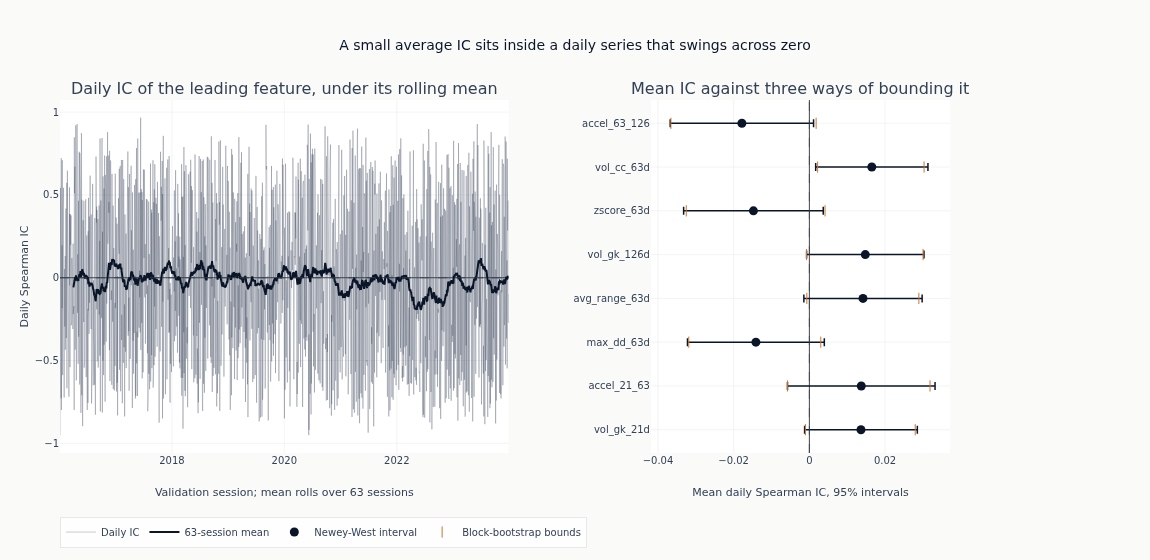

In [16]:
interval_features = list(reversed(leaders))
_ = fig.add_trace(
    go.Scatter(
        x=[ic_uncertainty[name]["mean_ic"] for name in interval_features],
        y=interval_features,
        mode="markers",
        marker={"color": COLORS["blue"], "size": 9},
        error_x={
            "type": "data",
            "symmetric": False,
            "array": [
                ic_uncertainty[name]["ci_hac_upper"] - ic_uncertainty[name]["mean_ic"]
                for name in interval_features
            ],
            "arrayminus": [
                ic_uncertainty[name]["mean_ic"] - ic_uncertainty[name]["ci_hac_lower"]
                for name in interval_features
            ],
            "color": COLORS["blue"],
            "thickness": 1.5,
        },
        name="Newey-West interval",
    ),
    row=1,
    col=2,
)
_ = fig.add_trace(
    go.Scatter(
        x=[ic_uncertainty[name][bound] for name in interval_features for bound in BOOT_BOUNDS],
        y=[name for name in interval_features for _ in BOOT_BOUNDS],
        mode="markers",
        marker={"color": COLORS["copper"], "size": 8, "symbol": "line-ns-open"},
        name="Block-bootstrap bounds",
    ),
    row=1,
    col=2,
)
_ = fig.add_vline(
    x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=2
)
fig.update_layout(
    title="A small average IC sits inside a daily series that swings across zero",
    height=560,
    width=1150,
    margin={"l": 60, "r": 200},
    legend={"orientation": "h", "y": -0.18},
)
fig.update_yaxes(title_text="Daily Spearman IC", row=1, col=1)
fig.update_xaxes(
    title_text=f"Validation session; mean rolls over {IC_ROLLING_WINDOW} sessions",
    row=1,
    col=1,
)
fig.update_xaxes(title_text="Mean daily Spearman IC, 95% intervals", row=1, col=2)
fig.show()

### Fold Stability

The full validation IC determines direction. Stability is the share of fold
means with that same direction, so stable negative and positive associations
receive symmetric treatment.

In [17]:
fold_stats = {}
for feature, full_stats in ic_results.items():
    fold_means = []
    for fold in sorted(ic_timeseries[feature]["fold"].unique().to_list()):
        fold_values = (
            ic_timeseries[feature].filter(pl.col("fold") == fold).sort(DATE_COL)["ic"].to_numpy()
        )
        if len(fold_values) >= MIN_FOLD_DAYS:
            fold_means.append(float(np.mean(fold_values)))
    if not fold_means:
        continue
    direction = 1 if full_stats["mean_ic"] >= 0 else -1
    sign_consistency = sum((value * direction) > 0 for value in fold_means) / len(fold_means)
    fold_stats[feature] = {
        "n_folds": len(fold_means),
        "direction": "positive" if direction > 0 else "negative",
        "sign_consistency": sign_consistency,
        "worst_fold_ic": min(fold_means),
        "best_fold_ic": max(fold_means),
        "median_fold_ic": float(np.median(fold_means)),
        "fold_ics": fold_means,
    }

print(f"Fold stability computed for {len(fold_stats)} features")

Fold stability computed for 54 features


One number per feature hides whether the folds agreed. Each row below carries every
fold mean, its median, and the fold that went furthest against the rest, so a
feature whose association rests on one window is separable from one that repeated.

In [18]:
def signed_direction(feature: str) -> int:
    """+1 where the feature's overall IC is positive, -1 where it is negative."""
    return 1 if fold_stats[feature]["direction"] == "positive" else -1

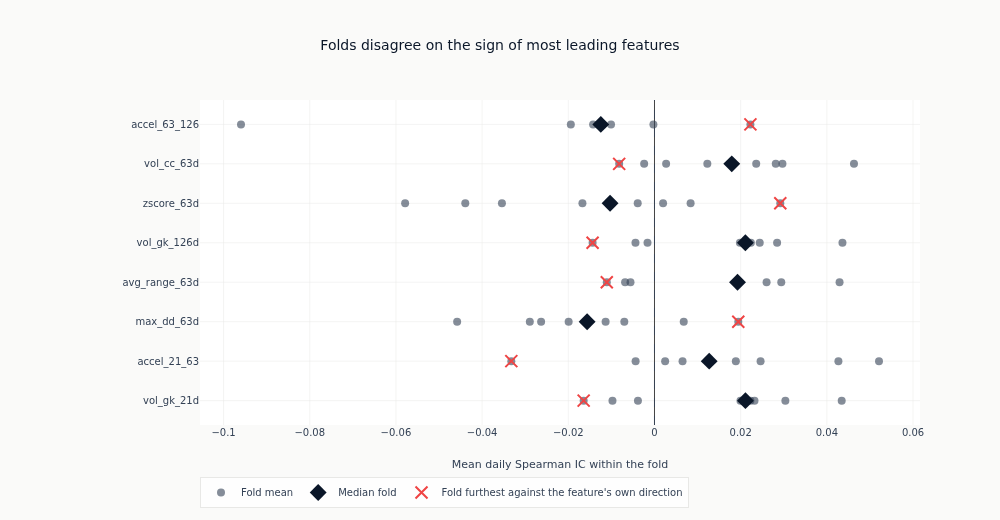

In [19]:
stability_features = [name for name in reversed(leaders) if name in fold_stats]
fig = go.Figure()
_ = fig.add_trace(
    go.Scatter(
        x=[value for name in stability_features for value in fold_stats[name]["fold_ics"]],
        y=[name for name in stability_features for _ in fold_stats[name]["fold_ics"]],
        mode="markers",
        marker={"color": COLORS["neutral"], "size": 8, "opacity": 0.6},
        name="Fold mean",
    )
)
_ = fig.add_trace(
    go.Scatter(
        x=[fold_stats[name]["median_fold_ic"] for name in stability_features],
        y=stability_features,
        mode="markers",
        marker={"color": COLORS["blue"], "size": 13, "symbol": "diamond"},
        name="Median fold",
    )
)
_ = fig.add_trace(
    go.Scatter(
        x=[
            min(fold_stats[name]["fold_ics"], key=lambda value: value * signed_direction(name))
            for name in stability_features
        ],
        y=stability_features,
        mode="markers",
        marker={
            "color": COLORS["negative"],
            "size": 12,
            "symbol": "x-thin",
            "line": {"width": 2, "color": COLORS["negative"]},
        },
        name="Fold furthest against the feature's own direction",
    )
)
_ = fig.add_vline(x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
fig.update_layout(
    title="Folds disagree on the sign of most leading features",
    xaxis_title="Mean daily Spearman IC within the fold",
    height=520,
    width=1000,
    margin={"l": 200},
    legend={"orientation": "h", "y": -0.16},
)
fig.show()

## 4. Multiple Testing

A p-value is only interpretable against the set of tests it came out of, so the
search is declared before the adjustment is applied. The candidate set is generated
by `03_financial_features` from the window register in `setup.yaml` and by
`04_model_based_features` from its four estimator families; no feature here was
chosen after seeing an IC. Benjamini-Hochberg then controls the false discovery rate
across every feature with a computable cross-sectional IC on the primary label.
Naive and Newey-West significance counts are kept distinct.

In [20]:
searched_set = {
    "candidate features generated": len(all_feature_cols),
    "cleared correctness screens": sum(correctness.values()),
    "tested on the primary label": len(ic_results),
    "declared label horizons": len(LABEL_HORIZONS),
}
for description, count in searched_set.items():
    print(f"{description:<32} {count}")

candidate features generated     63
cleared correctness screens      59
tested on the primary label      54
declared label horizons          3


In [21]:
feature_names = list(ic_results)
hac_p_values = [
    value if np.isfinite(value := ic_results[feature]["p_value"]) else 1.0
    for feature in feature_names
]
fdr_result = benjamini_hochberg_fdr(hac_p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": [
            "model_based" if feature in temporal_cols else "financial" for feature in feature_names
        ],
        "ic_mean": [ic_results[feature]["mean_ic"] for feature in feature_names],
        "naive_t": [ic_results[feature]["naive_t_stat"] for feature in feature_names],
        "hac_se": [ic_results[feature]["hac_se"] for feature in feature_names],
        "hac_t": [ic_results[feature]["t_stat"] for feature in feature_names],
        "hac_p": hac_p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
    }
).sort(pl.col("ic_mean").abs(), descending=True)

n_naive = sum(abs(ic_results[feature]["naive_t_stat"]) > 1.96 for feature in feature_names)
n_hac = sum(hac_p < 0.05 for hac_p in hac_p_values)
n_fdr = int(fdr_result["n_rejected"])
print(f"Naive significant (|t| > 1.96): {n_naive}")
print(f"HAC significant (p < 0.05):     {n_hac}")
print(f"FDR significant (q < 0.05):     {n_fdr}")

leading_row = eval_summary.row(0, named=True) if len(eval_summary) else None
if leading_row:
    print(
        f"Largest absolute estimate: {leading_row['feature']} "
        f"(mean daily IC {leading_row['ic_mean']:+.4f}, "
        f"Newey-West t {leading_row['hac_t']:+.2f})"
    )

Naive significant (|t| > 1.96): 1
HAC significant (p < 0.05):     1
FDR significant (q < 0.05):     0
Largest absolute estimate: accel_63_126 (mean daily IC -0.0178, Newey-West t -1.85)


Of 63 candidate features, 59 clear the correctness screens and 54 have a computable
cross-sectional IC on the primary label across 8 validation folds. One of those
clears the Newey-West screen, and none clears the Benjamini-Hochberg adjustment at
q < 0.05. The largest absolute estimate is a mean daily IC of -0.0178, at a
Newey-West t of -1.85.

In [22]:
top_n = min(20, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Ranked mean IC, split by the false-discovery decision",
        "Newey-West leaves most t-statistics near naive estimates",
    ),
    horizontal_spacing=0.18,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = top.filter(pl.col("fdr_sig") == cleared)
    _ = fig.add_trace(
        go.Bar(
            x=arm["ic_mean"],
            y=arm["feature"],
            orientation="h",
            marker_color=color,
            text=[f"{value:+.3f}" for value in arm["ic_mean"]],
            textposition="inside",
            name=name,
        ),
        row=1,
        col=1,
    )

The companion panel compares naive and Newey-West inference. Points near the
diagonal have little serial-correlation adjustment; departures show where it
matters for the significance screen.

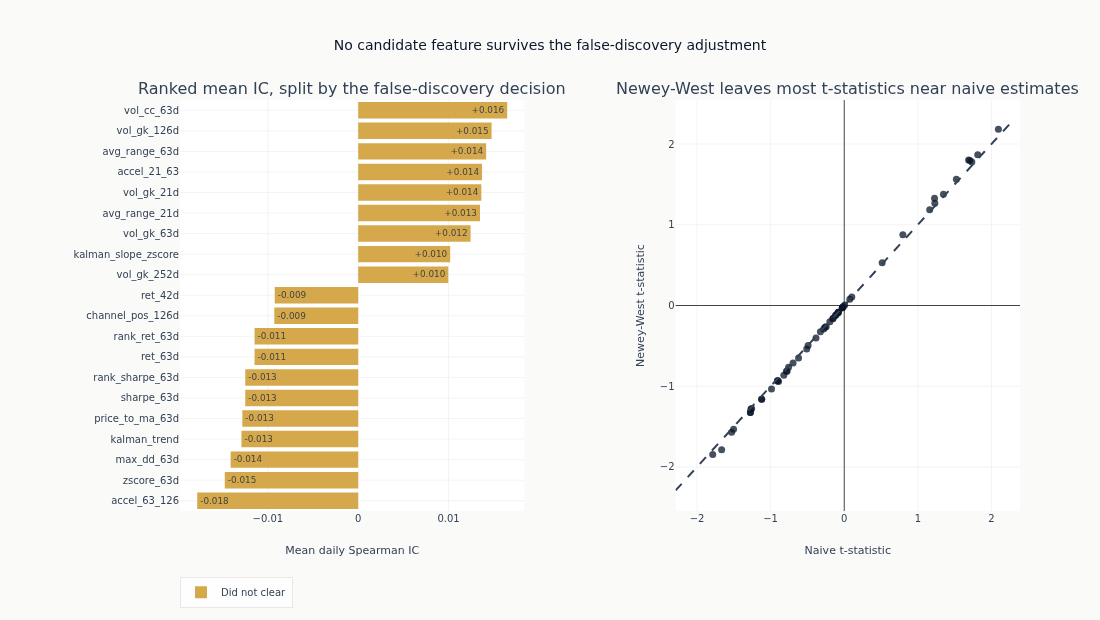

In [23]:
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_t"],
        y=eval_summary["hac_t"],
        mode="markers",
        marker={"color": COLORS["blue"], "size": 7, "opacity": 0.75},
        text=eval_summary["feature"],
        showlegend=False,
    ),
    row=1,
    col=2,
)
finite_t = [
    abs(float(value))
    for column in ("naive_t", "hac_t")
    for value in eval_summary[column]
    if np.isfinite(value)
]
if finite_t:
    t_limit = max(finite_t) * 1.05
    fig.add_trace(
        go.Scatter(
            x=[-t_limit, t_limit],
            y=[-t_limit, t_limit],
            mode="lines",
            line={"color": COLORS["neutral"], "dash": "dash"},
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_layout(
    title="No candidate feature survives the false-discovery adjustment",
    height=620,
    width=1100,
    margin={"l": 180},
    barmode="relative",
    legend={"orientation": "h", "y": -0.16},
)
fig.update_xaxes(title_text="Mean daily Spearman IC", row=1, col=1)
fig.update_xaxes(title_text="Naive t-statistic", row=1, col=2)
fig.update_yaxes(title_text="Newey-West t-statistic", row=1, col=2)
fig.show()

### Association Across the Declared Label Horizons

The case study ships three forward-return labels, and a feature that predicts the
next session need not predict the next month. Each horizon is sealed on its own
label endpoint, so the longer ones evaluate over a shorter development window. The
information ratio beside the mean is the fold-level one: the average fold IC over
the dispersion of fold ICs, which separates a small association that repeats from a
larger one that does not.

In [24]:
def build_horizon_panel(label_name: str) -> pl.DataFrame:
    """Join the validation rows to one declared label, sealed at that label's horizon."""
    label_frame = pl.read_parquet(CASE_DIR / "labels" / f"{label_name}.parquet")
    panel = (
        validation_rows(fold_windows(LABEL_BUFFERS[label_name]))
        .join(financial, on=JOIN_COLS, how="inner")
        .join(label_frame, on=JOIN_COLS, how="inner")
        .sort([DATE_COL, "symbol"])
    )
    if MAX_SYMBOLS > 0:
        panel = panel.filter(pl.col("symbol").is_in(selected_symbols))
    return panel

In [25]:
horizon_rows = []
for label_name, horizon in sorted(LABEL_HORIZONS.items(), key=lambda item: item[1]):
    panel = build_horizon_panel(label_name)
    assert panel[DATE_COL].max() < HOLDOUT_START, f"{label_name} panel reaches the sealed holdout"
    for feature in leaders:
        series = compute_cross_sectional_ic(
            panel, feature=feature, return_col=label_name, min_periods=MIN_PERIODS
        )
        if len(series) < 20:
            continue
        fold_means = [
            float(part["ic"].mean())
            for part in series.partition_by("fold")
            if len(part) >= MIN_FOLD_DAYS
        ]
        dispersion = float(np.std(fold_means, ddof=1)) if len(fold_means) > 1 else np.nan
        horizon_rows.append(
            {
                "feature": feature,
                "horizon": horizon,
                "ic_mean": float(series["ic"].mean()),
                "icir": float(np.mean(fold_means)) / dispersion if dispersion else np.nan,
            }
        )

horizon_ic = pl.DataFrame(horizon_rows)
print(f"Horizon profile computed for {horizon_ic['feature'].n_unique()} features")

Horizon profile computed for 8 features


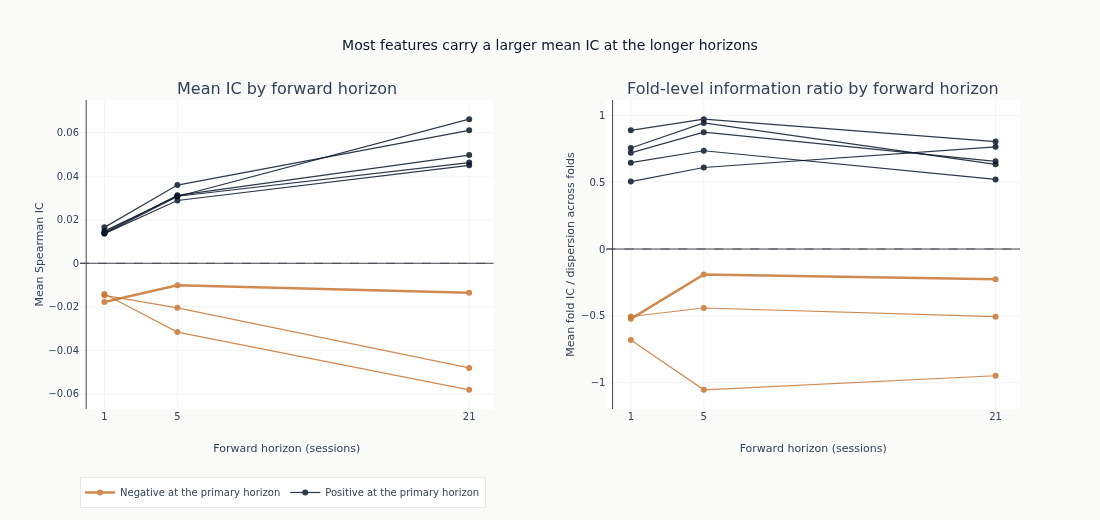

In [26]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Mean IC by forward horizon",
        "Fold-level information ratio by forward horizon",
    ),
    horizontal_spacing=0.12,
)
shown_direction = set()
for feature in leaders:
    profile = horizon_ic.filter(pl.col("feature") == feature).sort("horizon")
    if not len(profile):
        continue
    positive = float(profile["ic_mean"][0]) > 0
    group = "Positive at the primary horizon" if positive else "Negative at the primary horizon"
    style = {
        "color": COLORS["blue"] if positive else COLORS["copper"],
        "width": 2.5 if feature == leader else 1.2,
    }
    for column, column_index in (("ic_mean", 1), ("icir", 2)):
        first = column_index == 1 and group not in shown_direction
        _ = fig.add_trace(
            go.Scatter(
                x=profile["horizon"],
                y=profile[column],
                mode="lines+markers",
                line=style,
                opacity=0.85,
                name=group,
                legendgroup=group,
                showlegend=first,
                hovertext=feature,
            ),
            row=1,
            col=column_index,
        )
    shown_direction.add(group)
_ = fig.add_hline(y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
fig.update_layout(
    title="Most features carry a larger mean IC at the longer horizons",
    height=520,
    width=1100,
    legend={"orientation": "h", "y": -0.22},
)
horizon_ticks = sorted(LABEL_HORIZONS.values())
for column_index in (1, 2):
    fig.update_xaxes(
        title_text="Forward horizon (sessions)",
        tickmode="array",
        tickvals=horizon_ticks,
        row=1,
        col=column_index,
    )
fig.update_yaxes(title_text="Mean Spearman IC", row=1, col=1)
fig.update_yaxes(title_text="Mean fold IC / dispersion across folds", row=1, col=2)
fig.show()

## 5. Cross-Sectional Shape

Quantile membership is assigned within each date, never from the pooled
validation distribution. This preserves the cross-sectional question asked by
daily IC and avoids using future distributional information.

In [27]:
shape_features = eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list()[:12]
if not shape_features:
    shape_features = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feature in shape_features:
    valid = eval_panel.select([DATE_COL, feature, LABEL_COL]).drop_nulls()
    valid = valid.filter(pl.len().over(DATE_COL) >= N_QUANTILES)
    if len(valid) < N_QUANTILES * 20:
        continue
    shaped = valid.with_columns(
        (
            (pl.col(feature).rank(method="average").over(DATE_COL) - 1)
            * N_QUANTILES
            / pl.len().over(DATE_COL)
        )
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile")
    )
    q_means = shaped.group_by("quantile").agg(pl.col(LABEL_COL).mean()).sort("quantile")
    if len(q_means) != N_QUANTILES:
        continue
    means = q_means[LABEL_COL].to_list()
    quantile_spreads[feature] = means
    monotonicity_scores[feature] = float(spearmanr(range(N_QUANTILES), means).statistic)

print(f"Cross-sectional shape evaluated for {len(quantile_spreads)} features")

Cross-sectional shape evaluated for 10 features


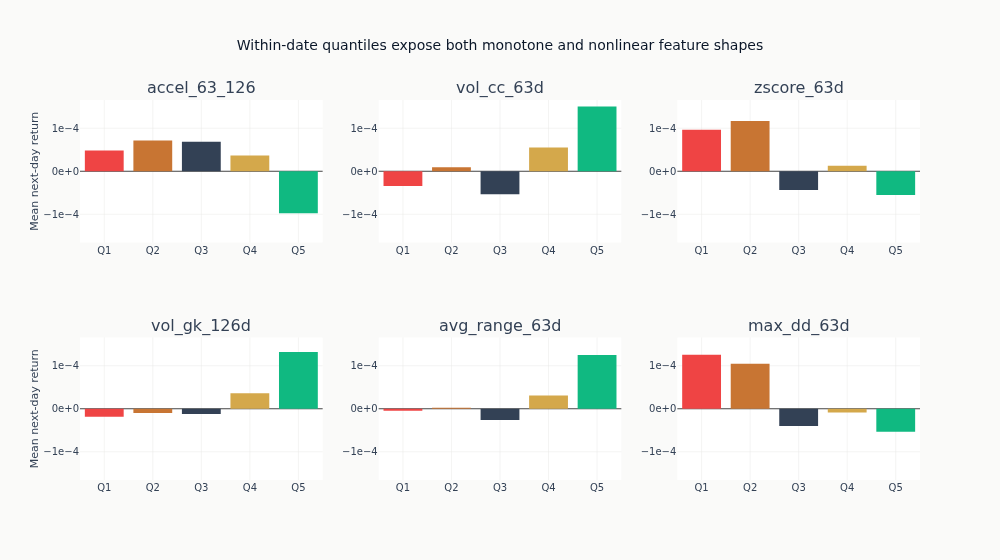

In [28]:
if quantile_spreads:
    features_to_show = list(quantile_spreads)[:6]
    figure_rows = (len(features_to_show) + 2) // 3
    fig = make_subplots(rows=figure_rows, cols=3, subplot_titles=features_to_show)
    quantile_colors = [
        COLORS["negative"],
        COLORS["copper"],
        COLORS["neutral"],
        COLORS["amber"],
        COLORS["positive"],
    ]
    for index, feature in enumerate(features_to_show):
        row, column = divmod(index, 3)
        fig.add_trace(
            go.Bar(
                x=[f"Q{quantile + 1}" for quantile in range(N_QUANTILES)],
                y=quantile_spreads[feature],
                marker_color=quantile_colors,
                showlegend=False,
            ),
            row=row + 1,
            col=column + 1,
        )
    fig.update_layout(
        title="Within-date quantiles expose both monotone and nonlinear feature shapes",
        height=280 * figure_rows,
        width=1000,
    )
    # One shared y range, so a weak profile cannot be rescaled to look like a strong one.
    span = max(abs(value) for feature in features_to_show for value in quantile_spreads[feature])
    fig.update_yaxes(range=[-1.1 * span, 1.1 * span], tickformat=".0e")
    for row in range(1, figure_rows + 1):
        fig.update_yaxes(title_text="Mean next-day return", row=row, col=1)
    fig.show()

## 6. Redundancy and Feature Families

Correlations are sampled across validation dates. A ranked pair chart exposes
the strongest redundancies without compressing 50-plus labels into an
unreadable heatmap. Features joined by a correlation above the cut below form a
cluster, and one member of each cluster stands for the rest: the one whose median
fold IC is largest and whose fold-to-fold dispersion is smallest, in that order.
Standing for a cluster does not promote a feature - the representative still has to
earn its own decision in the triage below.

In [29]:
def assign_feature_family(feature_name: str) -> str:
    """Map an FX feature to its economic or modeling family."""
    family_map = [
        (["kalman_"], "temporal_kalman"),
        (["hmm_"], "temporal_regime"),
        (["arima_"], "temporal_arima"),
        (["rank_"], "cross_sectional"),
        (["zscore", "channel_pos", "mom_skip"], "mean_reversion"),
        (["ret_"], "momentum"),
        (["vol_gk", "vol_cc", "vol_ratio", "avg_range"], "volatility"),
        (["sharpe_", "accel_"], "risk_adjusted"),
        (["usd_factor", "usd_beta"], "usd_factor"),
        (["rsi", "bollinger", "price_to_ma"], "technical"),
        (["carry"], "carry_proxy"),
        (["max_dd"], "drawdown"),
    ]
    lowered = feature_name.lower()
    for prefixes, family in family_map:
        if any(prefix in lowered for prefix in prefixes):
            return family
    return "other"

In [30]:
families = {feature: assign_feature_family(feature) for feature in all_feature_cols}
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
correlation_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(
    evaluable_features
)
correlation_matrix = correlation_data.to_pandas().corr(method="spearman")

high_correlation_pairs = []
for left_index in range(len(correlation_matrix)):
    for right_index in range(left_index + 1, len(correlation_matrix)):
        correlation = float(correlation_matrix.iloc[left_index, right_index])
        if np.isfinite(correlation) and abs(correlation) > REDUNDANCY_CUT:
            high_correlation_pairs.append(
                {
                    "left": str(correlation_matrix.columns[left_index]),
                    "right": str(correlation_matrix.columns[right_index]),
                    "correlation": correlation,
                }
            )

high_correlation_pairs.sort(key=lambda row: abs(row["correlation"]), reverse=True)
print(f"Feature pairs above the redundancy cut: {len(high_correlation_pairs)}")

Feature pairs above the redundancy cut: 186


### One Representative per Cluster

Transitively correlated features form a cluster, so the pairs above are collapsed
into connected components before a representative is chosen. A feature with no
recorded fold statistics cannot be compared on the criterion, so it is ranked last
within its cluster rather than dropped from it.

In [31]:
def cluster_key(feature: str) -> tuple[float, float]:
    """Rank within a cluster: largest median fold IC first, then tightest dispersion."""
    stats = fold_stats.get(feature)
    if not stats:
        return (-1.0, 0.0)
    return (abs(stats["median_fold_ic"]), -float(np.std(stats["fold_ics"], ddof=0)))

In [32]:
component_of: dict[str, str] = {feature: feature for feature in evaluable_features}


def root(feature: str) -> str:
    """Representative label of the connected component a feature currently sits in."""
    while component_of[feature] != feature:
        component_of[feature] = component_of[component_of[feature]]
        feature = component_of[feature]
    return feature


for pair in high_correlation_pairs:
    left_root, right_root = root(pair["left"]), root(pair["right"])
    if left_root != right_root:
        component_of[left_root] = right_root

clusters: dict[str, list[str]] = {}
for feature in evaluable_features:
    clusters.setdefault(root(feature), []).append(feature)

representative = {}
for members in clusters.values():
    chosen = max(members, key=cluster_key)
    for member in members:
        representative[member] = chosen

redundant_clusters = {name: members for name, members in clusters.items() if len(members) > 1}
print(f"Correlation clusters with more than one member: {len(redundant_clusters)}")
print(f"Features standing for a cluster: {len(set(representative.values()))}")

Correlation clusters with more than one member: 4
Features standing for a cluster: 11


In [33]:
def pair_label(pair: dict) -> str:
    """Name both members, marking whichever of them stands for their cluster."""
    return " / ".join(
        f"{member}*" if representative[member] == member else member
        for member in (pair["left"], pair["right"])
    )

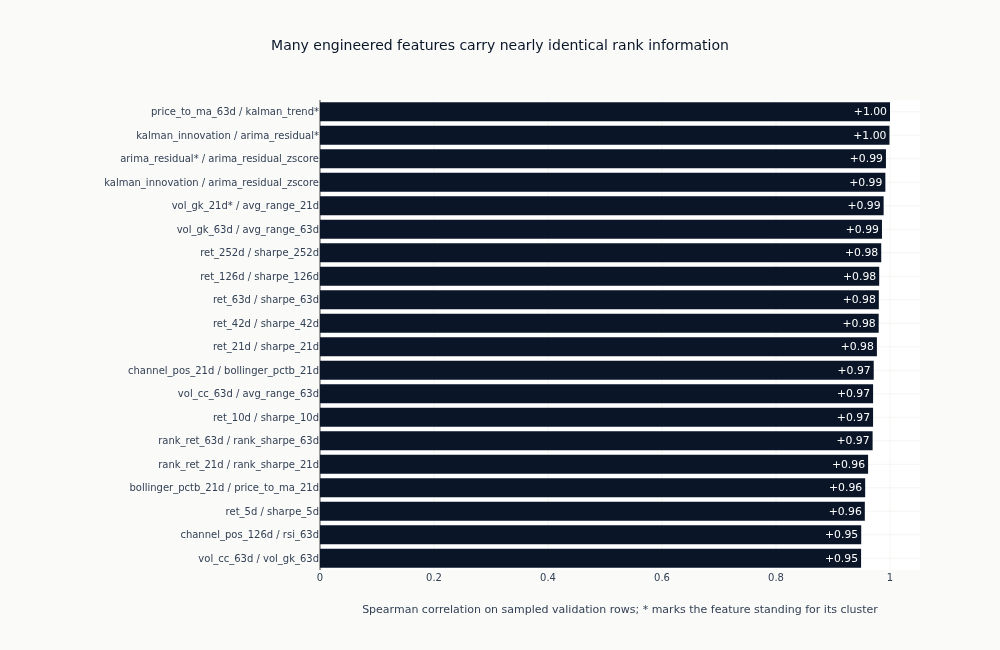

In [34]:
if high_correlation_pairs:
    correlation_plot = pl.DataFrame(
        [
            {"pair": pair_label(pair), "correlation": pair["correlation"]}
            for pair in high_correlation_pairs[:20]
        ]
    ).sort("correlation")
    fig = go.Figure(
        go.Bar(
            x=correlation_plot["correlation"],
            y=correlation_plot["pair"],
            orientation="h",
            marker_color=[
                COLORS["blue"] if value > 0 else COLORS["copper"]
                for value in correlation_plot["correlation"]
            ],
            text=[f"{value:+.2f}" for value in correlation_plot["correlation"]],
            textposition="inside",
        )
    )
    fig.update_layout(
        title="Many engineered features carry nearly identical rank information",
        xaxis_title=(
            "Spearman correlation on sampled validation rows; "
            "* marks the feature standing for its cluster"
        ),
        height=650,
        width=1000,
        margin={"l": 320},
    )
    fig.show()

## 7. Diagnostic Triage

`PROCEED` means a feature merits multivariate evaluation. It is not a final
model-selection decision. `STOP` is reserved for failed correctness screens;
market-level variables and weak standalone associations remain available for
interactions under `REVISE`.

Two arms can promote a feature, and the ledger records which one fired. The first
is confirmatory: the feature cleared the false-discovery adjustment over the
declared search. The second is exploratory in the sense of book Section 7.4: it
promotes on fold stability and effect size rather than on significance, so that a
small cross-section cannot empty the menu, and a feature promoted through it has
not been confirmed by anything.

In [35]:
fdr_significant = set(eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list())
triage = {}
for feature in all_feature_cols:
    if not correctness[feature]:
        triage[feature] = ("STOP", "correctness_fail")
    elif feature in date_level_features:
        triage[feature] = ("REVISE", "date_level_conditioner")
    elif feature not in ic_results:
        triage[feature] = ("REVISE", "insufficient_validation_data")
    elif feature in fdr_significant:
        triage[feature] = ("PROCEED", "fdr_significant")
    elif (
        fold_stats.get(feature, {}).get("sign_consistency", 0) >= STABILITY_THRESHOLD
        and abs(ic_results[feature]["mean_ic"]) >= IC_THRESHOLD
    ):
        triage[feature] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feature] = ("REVISE", "weak_standalone_association")

### Persist the Diagnostic Ledger

The ledger retains every component behind the decision, including direction,
fold consistency, multiplicity adjustment, coverage, and staleness.

In [36]:
ledger_rows = []
for feature in all_feature_cols:
    decision, note = triage[feature]
    summary_match = eval_summary.filter(pl.col("feature") == feature)
    ledger_rows.append(
        {
            "feature": feature,
            "family": families[feature],
            "source": "model_based" if feature in temporal_cols else "financial",
            "ic_mean": ic_results.get(feature, {}).get("mean_ic"),
            "hac_t": ic_results.get(feature, {}).get("t_stat"),
            "hac_p": ic_results.get(feature, {}).get("p_value"),
            "fdr_p": summary_match["fdr_p"][0] if len(summary_match) else None,
            "fdr_sig": bool(summary_match["fdr_sig"][0]) if len(summary_match) else False,
            "fold_direction": fold_stats.get(feature, {}).get("direction"),
            "sign_consistency": fold_stats.get(feature, {}).get("sign_consistency"),
            "worst_fold_ic": fold_stats.get(feature, {}).get("worst_fold_ic"),
            "monotonicity": monotonicity_scores.get(feature),
            "coverage": coverage[feature],
            "staleness": staleness[feature],
            "decision": decision,
            "note": note,
        }
    )

triage_ledger = pl.DataFrame(ledger_rows).sort(["decision", "feature"])
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")

ic_frames = [
    series.with_columns(pl.lit(feature).alias("feature"))
    for feature, series in ic_timeseries.items()
]
if ic_frames:
    pl.concat(ic_frames).select(["feature", DATE_COL, "fold", "ic", "n_obs"]).write_parquet(
        EVAL_DIR / "ic_timeseries.parquet"
    )

print("Wrote evaluation/triage_ledger.parquet")
print("Wrote evaluation/ic_timeseries.parquet")
print(triage_ledger.group_by("decision").len().sort("decision"))

Wrote evaluation/triage_ledger.parquet
Wrote evaluation/ic_timeseries.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 27  │
│ REVISE   ┆ 32  │
│ STOP     ┆ 4   │
└──────────┴─────┘


In [37]:
print(
    triage_ledger.group_by(["decision", "note"])
    .len()
    .sort(["decision", "note"])
    .rename({"len": "features"})
)

shape: (4, 3)
┌──────────┬─────────────────────────────┬──────────┐
│ decision ┆ note                        ┆ features │
│ ---      ┆ ---                         ┆ ---      │
│ str      ┆ str                         ┆ u32      │
╞══════════╪═════════════════════════════╪══════════╡
│ PROCEED  ┆ stable_and_above_threshold  ┆ 27       │
│ REVISE   ┆ date_level_conditioner      ┆ 5        │
│ REVISE   ┆ weak_standalone_association ┆ 27       │
│ STOP     ┆ correctness_fail            ┆ 4        │
└──────────┴─────────────────────────────┴──────────┘


The ledger records 27 PROCEED, 32 REVISE and 4 STOP decisions over the 63
candidates. Every PROCEED comes from the exploration arm, so no feature in this
case study advances on a confirmed association.

## Key Takeaways

Univariate screening answers whether a feature carries information about the label
on its own, and it answers nothing about whether a model built on several of them
trades. The method a reader takes from this notebook is the order the screens run
in: seal the label endpoint before anything is measured, compute the association
one decision time at a time and let a lag-aware estimator bound the average, ask
whether the folds agreed before believing the average, declare the search before
reading a p-value out of it, and record a decision per feature with the evidence
that produced it rather than a shortlist.

Two limits travel with the result. Rank correlation reads a monotone association
only, so a feature that matters through an interaction or a threshold is invisible
here and lands in `REVISE` rather than `STOP`. And the exploration arm promotes on
stability and effect size instead of significance, so a `PROCEED` from that arm is
a candidate for multivariate work and not a confirmed finding.

**Next**: `06_linear.py` evaluates linear models on the same canonical folds.